In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\kadit\MedicalPlan-Xray\data\processed\clean_data.csv")

In [3]:
df.head()

,user_id,gender,age,state_tier,occupation_class,salary_bracket,total_income_inr,is_smoker,family_members,medical_plan,annual_expenditure_inr
0,1,Male,19,Tier-2,Low-Risk,Tier-1,203736,0,5,Medium,89149
1,2,Female,20,Tier-1,Low-Risk,Tier-2,527824,0,6,Medium,115346
2,3,Male,46,Tier-2,High-Risk,Tier-1,233707,0,3,High,128494
3,4,Male,66,Tier-1,Low-Risk,Tier-1,330331,0,1,Medium,126971
4,5,Male,42,Tier-1,Low-Risk,Tier-2,879201,0,6,Medium,142701


1. Seprating features and targets:

In [4]:
X = df.drop(columns = ['medical_plan','user_id'])
y = df['medical_plan']

In [ ]:
#df['state_tier'].value_counts()

state_tier
Tier-1    425
Tier-2    314
Tier-3    241
Name: count, dtype: int64

2. Column type identification:

In [7]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['gender', 'state_tier', 'occupation_class', 'salary_bracket']
Numerical: ['age', 'total_income_inr', 'is_smoker', 'family_members', 'annual_expenditure_inr']


C:\Users\kadit\AppData\Local\Temp\ipykernel_22316\2474850768.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


3. Train Test Split:

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)  # 'stratify = y' here helps us balance the amount of training and testing data where there is imbalace.

4. Encoding Categorical Features:

| Type                                | Encoding         |
| ----------------------------------- | ---------------- |
| Gender (Male/Female)                | One-Hot Encoding |
| Salary Bracket                      | Ordinal Encoding |
| State Tier (Tier-1, Tier-2, Tier-3) | Ordinal Encoding |
| Occupation Class                    | Ordinal Encoding |
| Smoking Status                      | Already Binary (no operations)   |


5. Descriptive stats for checking the nature of function variables:

In [13]:
X_train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,784.0,45.721939,16.124649,18.0,32.0,45.0,59.0,75.0
total_income_inr,784.0,936322.936224,871104.237658,151934.0,410761.0,789421.0,1124310.0,4997509.0
is_smoker,784.0,0.207908,0.406070,0.0,0.0,0.0,0.0,1.0
family_members,784.0,3.535714,1.698546,1.0,2.0,4.0,5.0,6.0
annual_expenditure_inr,784.0,133948.502551,64648.838352,5000.0,84310.0,124310.0,179442.0,416505.0


6. Check skewness:

In [12]:
X_train[num_cols].skew().sort_values()

family_members           -0.030067
age                       0.027519
annual_expenditure_inr    0.599694
is_smoker                 1.442308
total_income_inr          2.311028
dtype: float64

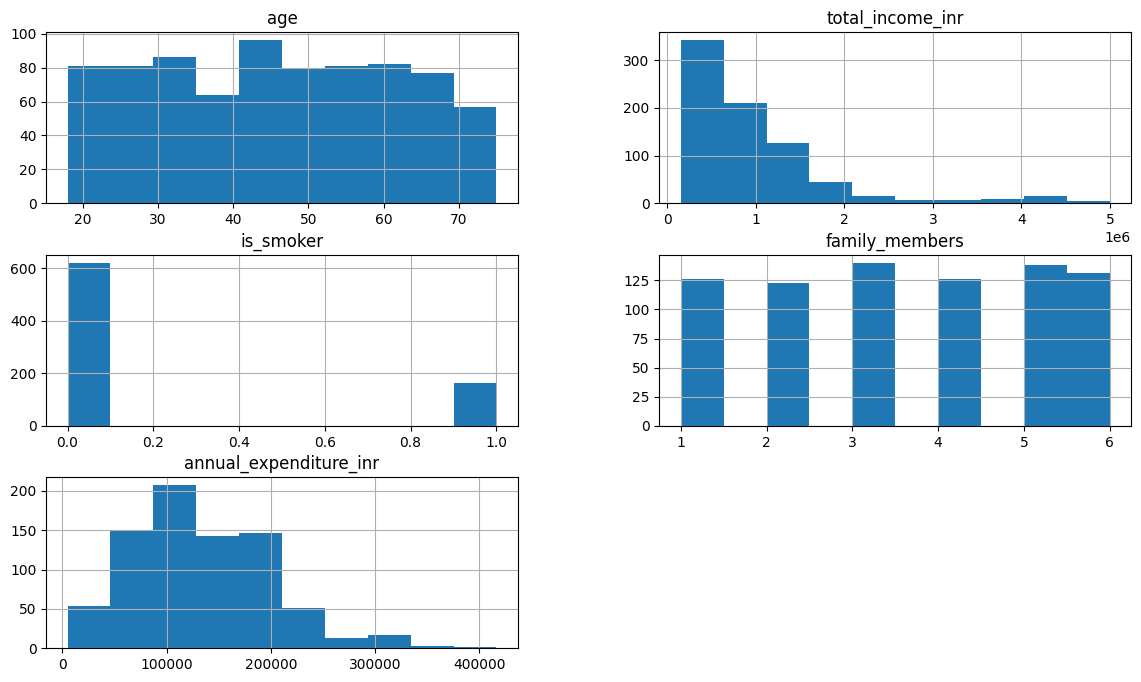

In [16]:
X_train[num_cols].hist(figsize=(14,8))
plt.show()

7. Plotting boxplot for potential outliers:

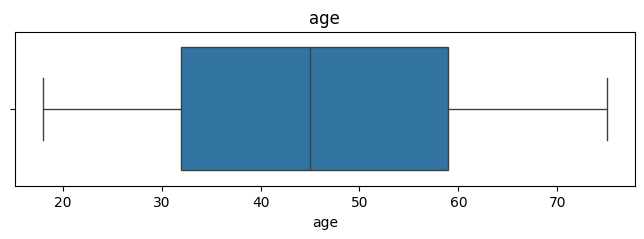

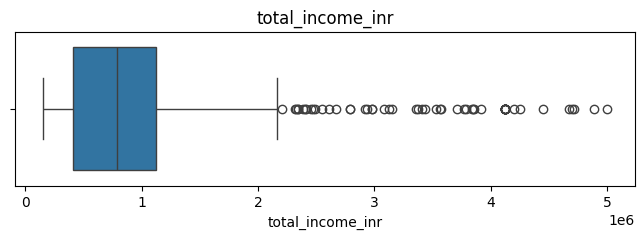

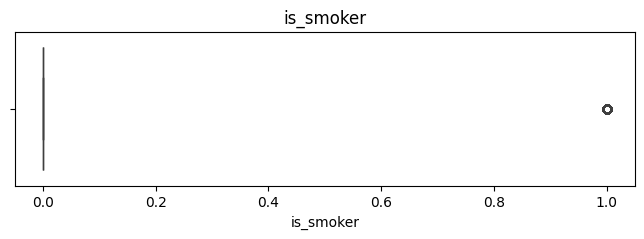

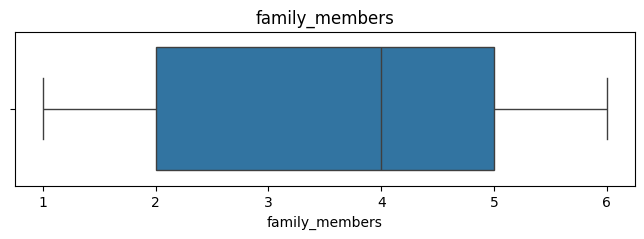

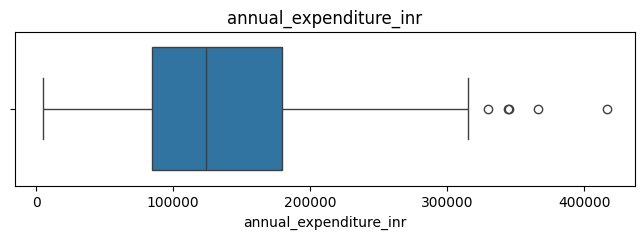

In [19]:
for col in num_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=X_train[col])
    plt.title(col)

8. Applying log transformer as we are preserving the outliers as they contain useful  info, therefore we won't trim or cap outliers just reduce their influence on the model:

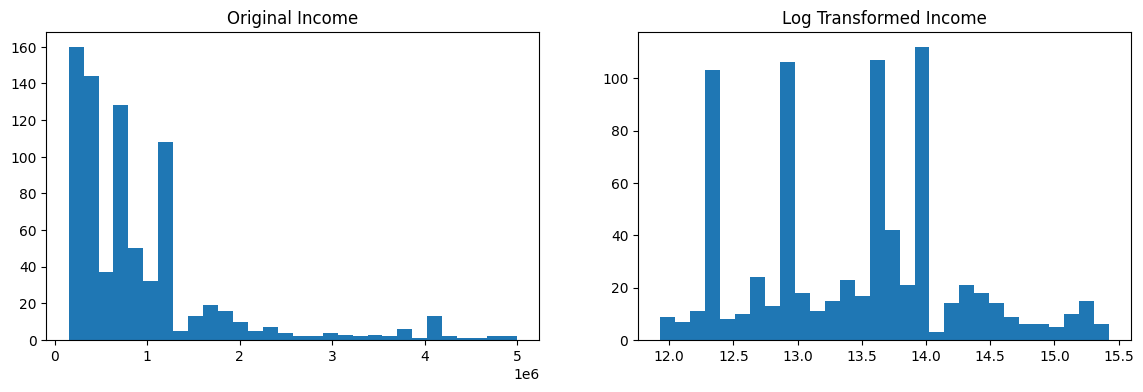

In [24]:
X_train['log_income'] = np.log1p(X_train['total_income_inr'])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(X_train['total_income_inr'], bins=30)
ax[0].set_title('Original Income')

ax[1].hist(X_train['log_income'], bins=30)
ax[1].set_title('Log Transformed Income')

plt.show()

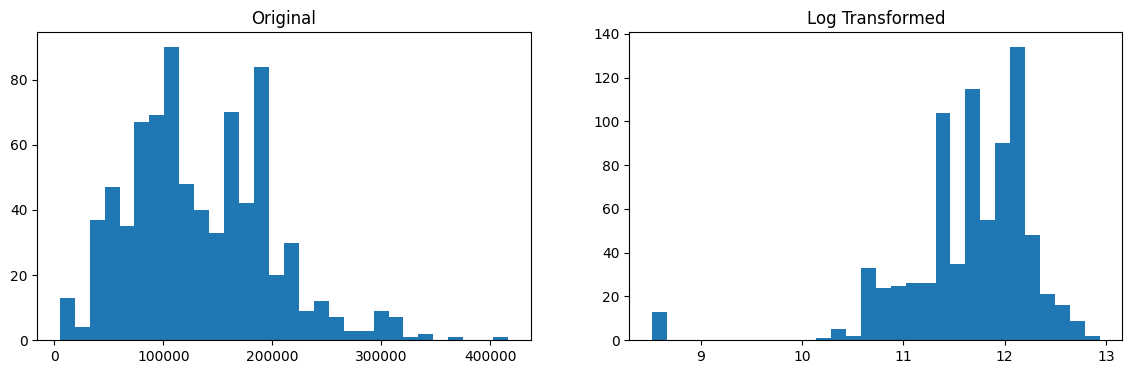

In [ ]:
'''X_train['log_expenditure'] = np.log1p(
    X_train['annual_expenditure_inr']
)

fig, ax = plt.subplots(1,2, figsize=(14,4))

ax[0].hist(
    X_train['annual_expenditure_inr'],
    bins=30
)
ax[0].set_title('Original')

ax[1].hist(
    X_train['log_expenditure'],
    bins=30
)
ax[1].set_title('Log Transformed')

plt.show()''' # leaving it as it is as there is no massive improvemnt

# Domain Feature Engineering

Usually in this we use 'Original data' rather than the 'transformed data' in order to preserve the real world business meaning.

Here we are going to apply feature contrcution that are further going to help are model perform precisely.

Pipeline to be followed:

Raw Data
->
Create Domain Features
->
Analyze New Features
->
Apply Transformations
->
Encoding
->
Scaling
->
Model

In [26]:
X_train['expense_ratio'] = (
    X_train['annual_expenditure_inr']
    / X_train['total_income_inr']
)

In [27]:
X_train['savings'] = (
    X_train['total_income_inr']
    - X_train['annual_expenditure_inr']
)

In [28]:
X_train['income_per_member'] = (
    X_train['total_income_inr']
    / X_train['family_members']
)


In [29]:
X_train['expenditure_per_member'] = (
    X_train['annual_expenditure_inr']
    / X_train['family_members']
)

In [30]:
new_features = [
    'expense_ratio',
    'savings',
    'income_per_member',
    'expenditure_per_member'
]

In [31]:
X_train[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
expense_ratio,784.0,0.249294,0.239371,0.001190,0.103492,0.172612,0.316376,1.699934e+00
savings,784.0,802374.433673,865858.298997,-150807.000000,238423.500000,608495.000000,960000.000000,4.911126e+06
income_per_member,784.0,350674.569537,452077.118202,26956.333333,131570.166667,206046.500000,379837.916667,4.120943e+06
expenditure_per_member,784.0,48153.795047,37443.406610,833.333333,25329.587500,37371.375000,55249.375000,2.304220e+05


here we need to mark one thing, as 'savings' has min value in -ve , we can't apply log transform on it.

In [32]:
X_train[new_features].skew().sort_values()

expenditure_per_member    2.176719
savings                   2.324127
expense_ratio             2.513057
income_per_member         4.181055
dtype: float64

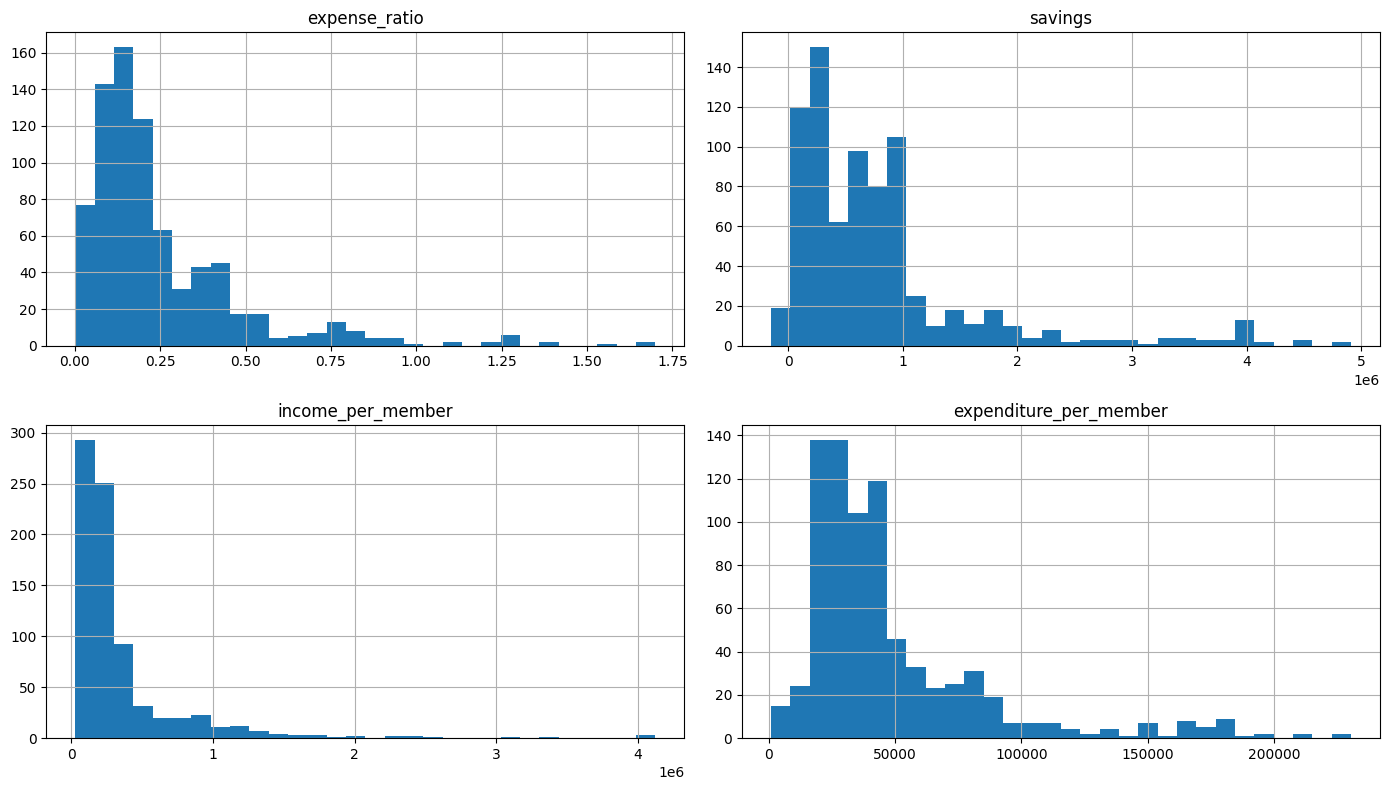

In [34]:
X_train[new_features].hist(
    figsize=(14,8),
    bins=30
)

plt.tight_layout()
plt.show()

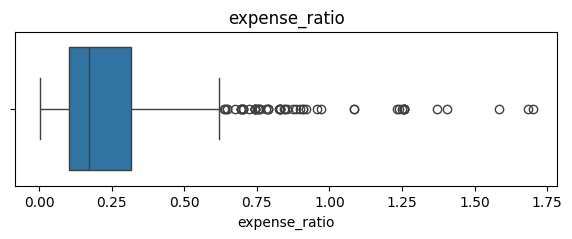

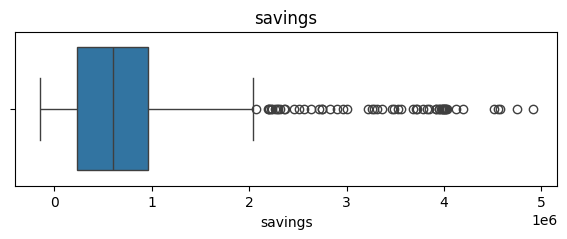

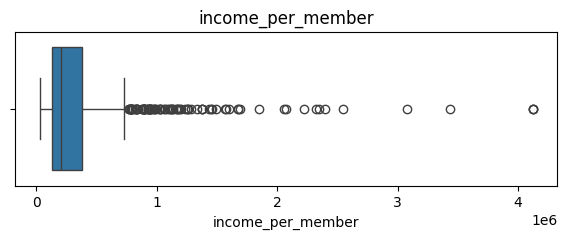

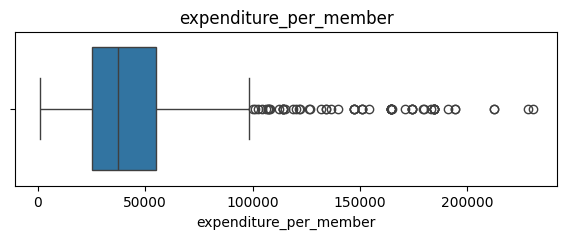

In [35]:
for col in new_features:
    plt.figure(figsize=(7,2))
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()

1. Checking if all the newly created features are necessary or not as further while applying linear regression or liner models can cause the issue of multicollinearity as there are highly corelate features:

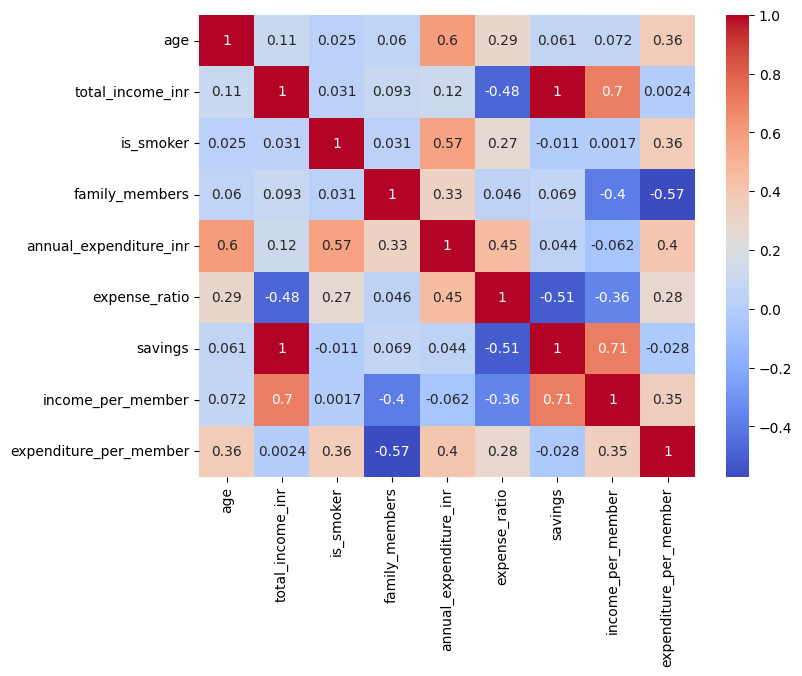

In [38]:
all_num_features = num_cols + new_features

corr = X_train[all_num_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()